In [1]:
import requests
import pandas as pd
import time

KEYWORDS = [
    "Smart Phones",
    "Washing Machines",
    "Laptop",
    "headphones",
    "smartwatch",
    "refrigerator",
    "gaming laptop",
    "television",
    "speakers",
    "camera"
]

API_KEY = "d6604566c4ba2fcf4d2e996712b8e125a79198b56ef16d3c7f6224baee3df4f7"
url = "https://serpapi.com/search.json"

all_products = []

for keyword in KEYWORDS:

    print(f"\nSearching: {keyword}")

    keyword_count = 0
    start = 0

    while keyword_count < 100:

        params = {
            "engine": "google_shopping_light",
            "q": keyword,
            "location": "India",
            "start": start,
            "api_key": API_KEY,
            "num": 40
        }

        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f"Request failed: {response.status_code}")
            break

        data = response.json()

        results = data.get("shopping_results", [])

        if not results:
            print(f"No more results at start={start}")
            break

        for item in results:
            all_products.append({
                "keyword": keyword,
                "title": item.get("title"),
                "price": item.get("extracted_price"),
                "raw_price": item.get("price"),
                "rating": item.get("rating"),
                "reviews": item.get("reviews"),
                "platform": item.get("source"),
                "position": item.get("position"),
                "delivery": item.get("delivery"),
                "link": item.get("product_link"),
                "thumbnail": item.get("thumbnail")
            })

        keyword_count += len(results)

        print(
            f"Page fetched | start={start} | "
            f"got={len(results)} | total={keyword_count}"
        )

        start += len(results)

        time.sleep(1)

    print(f"{keyword}: {keyword_count} results collected")

df = pd.DataFrame(all_products)

print("\n" + "=" * 50)
print(f"Total results collected: {len(df)}")
print(f"Final Shape: {df.shape}")

display(df.head())


Searching: Smart Phones
Page fetched | start=0 | got=40 | total=40
Page fetched | start=40 | got=40 | total=80
Page fetched | start=80 | got=40 | total=120
Smart Phones: 120 results collected

Searching: Washing Machines
Page fetched | start=0 | got=40 | total=40
Page fetched | start=40 | got=40 | total=80
Page fetched | start=80 | got=40 | total=120
Washing Machines: 120 results collected

Searching: Laptop
Page fetched | start=0 | got=40 | total=40
Page fetched | start=40 | got=40 | total=80
Page fetched | start=80 | got=40 | total=120
Laptop: 120 results collected

Searching: headphones
Page fetched | start=0 | got=40 | total=40
Page fetched | start=40 | got=40 | total=80
Page fetched | start=80 | got=40 | total=120
headphones: 120 results collected

Searching: smartwatch
Page fetched | start=0 | got=40 | total=40
Page fetched | start=40 | got=40 | total=80
Page fetched | start=80 | got=40 | total=120
smartwatch: 120 results collected

Searching: refrigerator
Page fetched | start=0

,keyword,title,price,raw_price,rating,reviews,platform,position,delivery,link,thumbnail
0,Smart Phones,Google Pixel 10a,499.00,$499.00,4.6,1400.0,Best Buy,1,Free delivery by Mon,https://www.google.com/search?ibp=oshop&q=Smar...,https://encrypted-tbn1.gstatic.com/shopping?q=...
1,Smart Phones,Samsung Galaxy Z Flip7 FE Smartphone,899.99,$899.99,4.6,960.0,Boost Mobile,2,None,https://www.google.com/search?ibp=oshop&q=Smar...,https://encrypted-tbn1.gstatic.com/shopping?q=...
2,Smart Phones,Apple iPhone 17,929.00,$929.00,4.6,15000.0,Apple,3,Free next-day delivery,https://www.google.com/search?ibp=oshop&q=Smar...,https://encrypted-tbn0.gstatic.com/shopping?q=...
3,Smart Phones,Motorola moto g play,99.99,$99.99,4.4,1100.0,Best Buy,4,Free delivery by Mon,https://www.google.com/search?ibp=oshop&q=Smar...,https://encrypted-tbn2.gstatic.com/shopping?q=...
4,Smart Phones,Tracfone Samsung Galaxy A16 128gb 5G,118.00,$118.00,3.9,793.0,Walmart - MGA Store,5,Free delivery,https://www.google.com/search?ibp=oshop&q=Smar...,https://encrypted-tbn1.gstatic.com/shopping?q=...


In [2]:


# 2. Data types of each column and check for expected numeric but not numeric
print("\nData types of each column and non-numeric check:")
df.info()


Data types of each column and non-numeric check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   keyword    1200 non-null   object 
 1   title      1200 non-null   object 
 2   price      1200 non-null   float64
 3   raw_price  1200 non-null   object 
 4   rating     1074 non-null   float64
 5   reviews    1074 non-null   float64
 6   platform   1197 non-null   object 
 7   position   1200 non-null   int64  
 8   delivery   750 non-null    object 
 9   link       1197 non-null   object 
 10  thumbnail  1200 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 103.3+ KB


In [3]:
df['raw_price'] = pd.to_numeric(
    df['raw_price']
      .astype(str)
      .str.replace('$', '', regex=False)
      .str.replace(',', '', regex=False),
    errors='coerce'
)

In [4]:
df['reviews'] = pd.to_numeric(
    df['reviews'],
    errors='coerce'
).astype('Int64')

In [5]:

# 2. Data types of each column and check for expected numeric but not numeric
print("\nData types of each column and non-numeric check:")
df.info()


Data types of each column and non-numeric check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   keyword    1200 non-null   object 
 1   title      1200 non-null   object 
 2   price      1200 non-null   float64
 3   raw_price  1168 non-null   float64
 4   rating     1074 non-null   float64
 5   reviews    1074 non-null   Int64  
 6   platform   1197 non-null   object 
 7   position   1200 non-null   int64  
 8   delivery   750 non-null    object 
 9   link       1197 non-null   object 
 10  thumbnail  1200 non-null   object 
dtypes: Int64(1), float64(3), int64(1), object(6)
memory usage: 104.4+ KB


In [6]:
for keyword in df['keyword'].unique():

    temp = df[df['keyword'] == keyword]

    print(
        keyword,
        "Total:", len(temp),
        "|  Unique Titles:", temp['title'].nunique()
    )

Smart Phones Total: 120 |  Unique Titles: 62
Washing Machines Total: 120 |  Unique Titles: 60
Laptop Total: 120 |  Unique Titles: 60
headphones Total: 120 |  Unique Titles: 86
smartwatch Total: 120 |  Unique Titles: 49
refrigerator Total: 120 |  Unique Titles: 77
gaming laptop Total: 120 |  Unique Titles: 90
television Total: 120 |  Unique Titles: 78
speakers Total: 120 |  Unique Titles: 62
camera Total: 120 |  Unique Titles: 59


In [ ]:
for keyword in df['keyword'].unique():

    temp = df[df['keyword'] == keyword]

    print(
        keyword,
        "Unique Links:",
        temp['link'].nunique()
    )

Smart Phones Unique Links: 87
Washing Machines Unique Links: 65
Laptop Unique Links: 52
headphones Unique Links: 103
smartwatch Unique Links: 49
refrigerator Unique Links: 54
gaming laptop Unique Links: 84
television Unique Links: 60
speakers Unique Links: 57
camera Unique Links: 71


In [13]:
print(df.isnull().sum())
print('-------------------------')
print(df.isnull().sum()/len(df)*100)

keyword        0
title          0
price          0
raw_price     32
rating       126
reviews      126
platform       3
position       0
delivery     450
link           3
thumbnail      0
dtype: int64
-------------------------
keyword       0.000000
title         0.000000
price         0.000000
raw_price     2.666667
rating       10.500000
reviews      10.500000
platform      0.250000
position      0.000000
delivery     37.500000
link          0.250000
thumbnail     0.000000
dtype: float64


In [15]:
print(df.head(20))

         keyword                                              title    price  \
0   Smart Phones                                   Google Pixel 10a   499.00   
1   Smart Phones               Samsung Galaxy Z Flip7 FE Smartphone   899.99   
2   Smart Phones                                    Apple iPhone 17   929.00   
3   Smart Phones                               Motorola moto g play    99.99   
4   Smart Phones               Tracfone Samsung Galaxy A16 128gb 5G   118.00   
5   Smart Phones                              Samsung Galaxy A37 5G    12.49   
6   Smart Phones                                      BLU G75 256GB   179.99   
7   Smart Phones                            Samsung Galaxy S25 Edge  1099.99   
8   Smart Phones                           Samsung Galaxy S26 Ultra    36.12   
9   Smart Phones                              Samsung Galaxy A17 5G   119.00   
10  Smart Phones                         AT&T Samsung Galaxy A16 5G    49.99   
11  Smart Phones  Motorola edge 2026 128

1.PLATFORM

In [16]:
df = df.dropna(subset=['platform']).copy()
print("Missing platform values:", df['platform'].isnull().sum())


Missing platform values: 0


In [18]:
print(df.isnull().sum())
print('-------------------------')
print(df.isnull().sum()/len(df)*100)

keyword        0
title          0
price          0
raw_price     29
rating       126
reviews      126
platform       0
position       0
delivery     447
link           0
thumbnail      0
dtype: int64
-------------------------
keyword       0.000000
title         0.000000
price         0.000000
raw_price     2.422723
rating       10.526316
reviews      10.526316
platform      0.000000
position      0.000000
delivery     37.343358
link          0.000000
thumbnail     0.000000
dtype: float64


2.DELIVERY

In [22]:
print(df['delivery'].value_counts(dropna=False))

delivery
Free delivery               464
None                        447
Free delivery by Mon         67
Free delivery by Wed         56
Free delivery by Fri         41
Free delivery by Thu         41
Free delivery by Tue         39
1 hour delivery $20          21
Free next-day delivery        9
Same-day delivery $10         4
Free delivery on $99+         3
Free delivery on $75+         3
Free delivery on $1,999+      1
Free delivery on $35+         1
Name: count, dtype: int64


In [24]:
print(
    df['delivery']
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2)
)

delivery
Free delivery               38.76
None                        37.34
Free delivery by Mon         5.60
Free delivery by Wed         4.68
Free delivery by Fri         3.43
Free delivery by Thu         3.43
Free delivery by Tue         3.26
1 hour delivery $20          1.75
Free next-day delivery       0.75
Same-day delivery $10        0.33
Free delivery on $99+        0.25
Free delivery on $75+        0.25
Free delivery on $1,999+     0.08
Free delivery on $35+        0.08
Name: proportion, dtype: float64


In [32]:
group_cols = ['keyword','platform']

print("Number of unique groups:",
      df.groupby(group_cols).ngroups)

Number of unique groups: 334


In [33]:
group_counts = (
    df
    .groupby(group_cols)
    .size()
    .reset_index(name='count')
)

display(group_counts)

,keyword,platform,count
0,Laptop,Adorama,2
1,Laptop,Apple,7
2,Laptop,B&H Photo-Video-Audio,4
3,Laptop,BJ's Wholesale Club,2
4,Laptop,Best Buy,31
...,...,...,...
329,television,eBay - haniretailstore,1
330,television,eBay - renleys,2
331,television,mcgrocer.com,3
332,television,mercari.com,3


In [38]:
delivery_check = (
    df.groupby(['keyword', 'platform'])['delivery']
    .agg(
        total='size',
        missing='count'
    )
)
print(delivery_check)

                                   total  missing
keyword    platform                              
Laptop     Adorama                     2        2
           Apple                       7        7
           B&H Photo-Video-Audio       4        3
           BJ's Wholesale Club         2        2
           Best Buy                   31       13
...                                  ...      ...
television eBay - haniretailstore      1        1
           eBay - renleys              2        2
           mcgrocer.com                3        3
           mercari.com                 3        0
           mynavyexchange.com          1        1

[334 rows x 2 columns]


In [39]:
delivery_check = (
    df.groupby(['keyword'])['delivery']
    .agg(
        total='size',
        missing='count'
    )
)
print(delivery_check)

                  total  missing
keyword                         
Laptop              120       89
Smart Phones        120       72
Washing Machines    120       42
camera              120       83
gaming laptop       120       73
headphones          120       82
refrigerator        120       49
smartwatch          120       81
speakers            120       80
television          117       99


In [41]:
df['delivery'] = df['delivery'].fillna('Unknown')

In [43]:
print(df['delivery'].isnull().sum())
print(df['delivery'].value_counts())

0
delivery
Free delivery               464
Unknown                     447
Free delivery by Mon         67
Free delivery by Wed         56
Free delivery by Fri         41
Free delivery by Thu         41
Free delivery by Tue         39
1 hour delivery $20          21
Free next-day delivery        9
Same-day delivery $10         4
Free delivery on $99+         3
Free delivery on $75+         3
Free delivery on $1,999+      1
Free delivery on $35+         1
Name: count, dtype: int64


2.REVIEWS

In [ ]:
def clean_reviews(reviews_series):
    cleaned_series = (
        reviews_series.astype(str)
        .str.lower()
        .str.replace(r'[^\d]', '', regex=True)
    )

    numeric_series = pd.to_numeric(
        cleaned_series,
        errors='coerce'
    )

    return numeric_series


# Clean reviews
df['reviews'] = clean_reviews(df['reviews'])


# Group-wise smart imputation
def smart_impute(group):

    q1 = group['reviews'].quantile(0.25)
    q3 = group['reviews'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers_exist = (
        ((group['reviews'] < lower) |
         (group['reviews'] > upper))
        .sum() > 0
    )

    if outliers_exist:
        fill_value = group['reviews'].median()
        method = "Median"
    else:
        fill_value = group['reviews'].mean()
        method = "Mean"

    missing_count = group['reviews'].isna().sum()

    if missing_count > 0:
        print(
            f"Group: keyword={group.name[0]}, "
            f"platform={group.name[1]}, "
        )
        print(f"Missing values: {missing_count}")
        print(f"Imputation method: {method}")
        print(f"Imputation value: {fill_value}")
        print("-" * 50)

    group['reviews'] = group['reviews'].fillna(fill_value)

    return group

df= (
    df
    .groupby(
        ['keyword', 'platform'],
        group_keys=False
    )
    .apply(smart_impute)
)

# Remaining missing values (if any)
# df['reviews'] = (
#     df['reviews']
#     .fillna(df['reviews'].median())
# )

# Convert to integer
df['reviews'] = df['reviews'].round().astype('Int64')

print("Missing values:", df['reviews'].isnull().sum())
print(df['reviews'].dtype)

display(df['reviews'].describe())

Group: keyword=Laptop, platform=Best Buy, 
Missing values: 4
Imputation method: Median
Imputation value: 600.0
--------------------------------------------------
Group: keyword=Laptop, platform=Electronic Express, 
Missing values: 2
Imputation method: Mean
Imputation value: nan
--------------------------------------------------
Group: keyword=Laptop, platform=Razer.com, 
Missing values: 3
Imputation method: Mean
Imputation value: nan
--------------------------------------------------
Group: keyword=Laptop, platform=Walmart - DUNHOO Mall, 
Missing values: 1
Imputation method: Mean
Imputation value: nan
--------------------------------------------------
Group: keyword=Laptop, platform=Walmart - PrimeGear Tech, 
Missing values: 1
Imputation method: Mean
Imputation value: nan
--------------------------------------------------
Group: keyword=Laptop, platform=geekompc.com, 
Missing values: 6
Imputation method: Mean
Imputation value: 1390.0
--------------------------------------------------
G

count           1132.0
mean      37715.208481
std      114834.815405
min               10.0
25%             1080.0
50%             6100.0
75%            28000.0
max          1500000.0
Name: reviews, dtype: Float64

In [46]:
overall_median = df['reviews'].median()

df['reviews'] = df['reviews'].fillna(overall_median)

df['reviews'] = df['reviews'].round().astype('Int64')

print("Overall median:", overall_median)
print("Missing values:", df['reviews'].isnull().sum())
print(df['reviews'].dtype)

Overall median: 6100.0
Missing values: 0
Int64


In [ ]:
import pandas as pd


# ============================================================
# 1. CLEAN REVIEWS
# ============================================================

def clean_reviews(reviews_series):

    cleaned_series = (
        reviews_series.astype(str)
        .str.lower()
        .str.replace(r'[^\d.]', '', regex=True)
    )

    numeric_series = pd.to_numeric(
        cleaned_series,
        errors='coerce'
    )

    return numeric_series


# Clean reviews
df['reviews'] = clean_reviews(df['reviews'])


# ============================================================
# 2. CALCULATE FALLBACK VALUES
# ============================================================

# Keyword-level median
keyword_medians = (
    df.groupby('keyword')['reviews']
      .median()
)

# Overall median
overall_median = df['reviews'].median()


# ============================================================
# 3. GROUP-WISE SMART IMPUTATION
# ============================================================

def smart_impute(group):

    # --------------------------------------------------------
    # Count valid and missing values
    # --------------------------------------------------------

    missing_count = group['reviews'].isna().sum()
    valid_count = group['reviews'].notna().sum()

    # If there are no missing values, return the group unchanged
    if missing_count == 0:
        return group


    # --------------------------------------------------------
    # If group has NO valid values
    # --------------------------------------------------------

    if valid_count == 0:

        # Get keyword from group name
        keyword = group.name[0]

        # Try keyword-level median
        keyword_median = keyword_medians.get(keyword)

        if pd.notna(keyword_median):

            fill_value = keyword_median
            method = "Keyword Median (Fallback)"

        else:

            # Final fallback
            fill_value = overall_median
            method = "Overall Median (Final Fallback)"


    # --------------------------------------------------------
    # If group has valid values
    # --------------------------------------------------------

    else:

        # Calculate Q1
        q1 = group['reviews'].quantile(0.25)

        # Calculate Q3
        q3 = group['reviews'].quantile(0.75)

        # Calculate IQR
        iqr = q3 - q1

        # Calculate lower boundary
        lower = q1 - 1.5 * iqr

        # Calculate upper boundary
        upper = q3 + 1.5 * iqr


        # ----------------------------------------------------
        # Check whether outliers exist
        # ----------------------------------------------------

        outliers_exist = (
            (
                (group['reviews'] < lower) |
                (group['reviews'] > upper)
            )
            .sum() > 0
        )


        # ----------------------------------------------------
        # Choose Median or Mean
        # ----------------------------------------------------

        if outliers_exist:

            fill_value = group['reviews'].median()
            method = "Median"

        else:

            fill_value = group['reviews'].mean()
            method = "Mean"


        # ----------------------------------------------------
        # Extra safety check
        # ----------------------------------------------------

        # If mean/median somehow becomes NaN,
        # use keyword-level median
        if pd.isna(fill_value):

            keyword = group.name[0]

            keyword_median = keyword_medians.get(keyword)

            if pd.notna(keyword_median):

                fill_value = keyword_median
                method = "Keyword Median (Fallback)"

            else:

                fill_value = overall_median
                method = "Overall Median (Final Fallback)"


    # ========================================================
    # 4. PRINT IMPUTATION INFORMATION
    # ========================================================

    print(
        f"Group: keyword={group.name[0]}, "
        f"platform={group.name[1]}"
    )

    print(f"Valid values: {valid_count}")
    print(f"Missing values: {missing_count}")
    print(f"Imputation method: {method}")
    print(f"Imputation value: {fill_value}")
    print("-" * 50)


    # ========================================================
    # 5. FILL MISSING VALUES
    # ========================================================

    group['reviews'] = group['reviews'].fillna(fill_value)

    return group


# ============================================================
# 6. APPLY GROUP-WISE IMPUTATION
# ============================================================

df = (
    df
    .groupby(
        ['keyword', 'platform'],
        group_keys=False
    )
    .apply(smart_impute)
)


# ============================================================
# 7. FINAL SAFETY CHECK
# ============================================================

# If any missing values somehow remain,
# use the overall median
df['reviews'] = df['reviews'].fillna(overall_median)


# ============================================================
# 8. ROUND AND CONVERT TO INTEGER
# ============================================================

df['reviews'] = (
    df['reviews']
    .round()
    .astype('Int64')
)


# ============================================================
# 9. CHECK FINAL RESULT
# ============================================================

print("Missing values:", df['reviews'].isnull().sum())
print("Data type:", df['reviews'].dtype)

display(df['reviews'].describe())

In [47]:
print(df.isnull().sum())
print('-------------------------')
print(df.isnull().sum()/len(df)*100)

keyword        0
title          0
price          0
raw_price     29
rating       126
reviews        0
platform       0
position       0
delivery       0
link           0
thumbnail      0
dtype: int64
-------------------------
keyword       0.000000
title         0.000000
price         0.000000
raw_price     2.422723
rating       10.526316
reviews       0.000000
platform      0.000000
position      0.000000
delivery      0.000000
link          0.000000
thumbnail     0.000000
dtype: float64


4.RAW PRICE 

In [49]:
# Remove rows where raw_price is null
df_price = df[df['raw_price'].notna()].copy()

# Check whether price and raw_price are the same
df_price['price_raw_price_same'] = (
    df_price['price'] == df_price['raw_price']
)

# Show rows where they are NOT the same
different_prices = df_price[
    df_price['price_raw_price_same'] == False
]

display(different_prices[['price', 'raw_price']])

# Count
print("Total non-null raw_price rows:", len(df_price))
print("Same price and raw_price:", df_price['price_raw_price_same'].sum())
print("Different price and raw_price:", len(different_prices))

,price,raw_price


Total non-null raw_price rows: 1168
Same price and raw_price: 1168
Different price and raw_price: 0


In [50]:
df['raw_price'] = df['raw_price'].fillna(df['price'])

In [51]:
print("Missing raw_price:", df['raw_price'].isna().sum())
print("Different price vs raw_price:",
      (df['price'] != df['raw_price']).sum())

Missing raw_price: 0
Different price vs raw_price: 0


5.RATING

In [ ]:
Q1 = df['rating'].quantile(0.25)
Q3 = df['rating'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['rating'] < lower_bound) |
    (df['rating'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 4.2
Q3: 4.7
IQR: 0.5
Lower bound: 3.45
Upper bound: 5.45
Number of outliers: 69


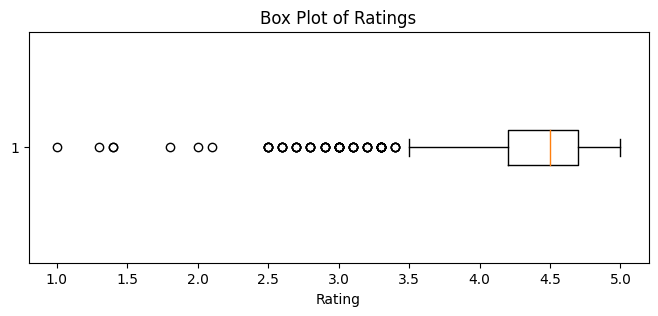

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.boxplot(df['rating'].dropna(), vert=False)
plt.xlabel('Rating')
plt.title('Box Plot of Ratings')
plt.show()

In [65]:
print("Skewness:", df['rating'].skew())

Skewness: -1.9839301350888086


In [63]:
rating_missing = (
    df.groupby(['keyword','platform'])['rating']
      .agg(
          total='size',
          missing=lambda x: x.isna().sum()
      )
)

rating_missing['missing_percentage'] = (
    rating_missing['missing'] /
    rating_missing['total'] * 100
)

print(rating_missing)

                                   total  missing  missing_percentage
keyword    platform                                                  
Laptop     Adorama                     2        0            0.000000
           Apple                       7        0            0.000000
           B&H Photo-Video-Audio       4        0            0.000000
           BJ's Wholesale Club         2        0            0.000000
           Best Buy                   31        4           12.903226
...                                  ...      ...                 ...
television eBay - haniretailstore      1        1          100.000000
           eBay - renleys              2        1           50.000000
           mcgrocer.com                3        0            0.000000
           mercari.com                 3        3          100.000000
           mynavyexchange.com          1        1          100.000000

[334 rows x 3 columns]


In [58]:
rating_missing = (
    df.groupby('keyword')['rating']
      .agg(
          total='size',
          missing=lambda x: x.isna().sum()
      )
)

rating_missing['missing_percentage'] = (
    rating_missing['missing'] /
    rating_missing['total'] * 100
)

print(rating_missing)

                  total  missing  missing_percentage
keyword                                             
Laptop              120       17           14.166667
Smart Phones        120        8            6.666667
Washing Machines    120        4            3.333333
camera              120        0            0.000000
gaming laptop       120       42           35.000000
headphones          120        9            7.500000
refrigerator        120       18           15.000000
smartwatch          120       10            8.333333
speakers            120        7            5.833333
television          117       11            9.401709


In [68]:
# ==================== RATING IMPUTATION ====================

# 1. Calculate overall mean of available ratings
overall_mean = df['rating'].mean()

# 2. Calculate mean rating for each keyword
keyword_mean = df.groupby('keyword')['rating'].transform('mean')

# 3. Calculate number of non-null ratings in each keyword + platform group
group_count = df.groupby(
    ['keyword', 'platform']
)['rating'].transform('count')

# 4. Calculate mean rating for each keyword + platform group
group_mean = df.groupby(
    ['keyword', 'platform']
)['rating'].transform('mean')

# 5. Fill missing ratings using keyword + platform mean
#    Only use the group mean if at least 5 valid ratings exist
df['rating'] = df['rating'].fillna(
    group_mean.where(group_count >= 5)
)

# 6. If still missing, use keyword-level mean
df['rating'] = df['rating'].fillna(keyword_mean)

# 7. If still missing, use overall mean
df['rating'] = df['rating'].fillna(overall_mean)

# 8. Round rating to 2 decimal places
df['rating'] = df['rating'].round(2)

# 9. Check result
print("Overall mean:", overall_mean)
print("Missing ratings after imputation:", df['rating'].isna().sum())
print("Rating data type:", df['rating'].dtype)

Overall mean: 4.384967320261437
Missing ratings after imputation: 0
Rating data type: float64


In [69]:
print(df.isnull().sum())
print('-------------------------')
print(df.isnull().sum()/len(df)*100)

keyword      0
title        0
price        0
raw_price    0
rating       0
reviews      0
platform     0
position     0
delivery     0
link         0
thumbnail    0
dtype: int64
-------------------------
keyword      0.0
title        0.0
price        0.0
raw_price    0.0
rating       0.0
reviews      0.0
platform     0.0
position     0.0
delivery     0.0
link         0.0
thumbnail    0.0
dtype: float64


Removing Duplicates

In [70]:
# Check for completely duplicate rows

duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))

if len(duplicate_rows) > 0:
    print("\nDuplicate rows:")
    display(duplicate_rows)
else:
    print("No completely duplicate rows found.")

Total duplicate rows: 41

Duplicate rows:


,keyword,title,price,raw_price,rating,reviews,platform,position,delivery,link,thumbnail
17,Smart Phones,Unihertz Titan 2 The Latest 5G QWERTY Physical...,489.99,489.99,4.90,1520,Unihertz,18,Free delivery,https://www.google.com/search?ibp=oshop&q=Smar...,https://encrypted-tbn2.gstatic.com/shopping?q=...
57,Smart Phones,Unihertz Titan 2 The Latest 5G QWERTY Physical...,489.99,489.99,4.90,1520,Unihertz,18,Free delivery,https://www.google.com/search?ibp=oshop&q=Smar...,https://encrypted-tbn2.gstatic.com/shopping?q=...
123,Washing Machines,LG 4.1 Cu. ft Agitator Top Load Washer with Tu...,548.97,548.97,4.20,57000,PC Richard & Son,4,Unknown,https://www.google.com/search?ibp=oshop&q=Wash...,https://encrypted-tbn1.gstatic.com/shopping?q=...
163,Washing Machines,LG 4.1 Cu. ft Agitator Top Load Washer with Tu...,548.97,548.97,4.20,57000,PC Richard & Son,4,Unknown,https://www.google.com/search?ibp=oshop&q=Wash...,https://encrypted-tbn1.gstatic.com/shopping?q=...
256,Laptop,"Microsoft Surface Laptop 13.8"" 2K Touchscreen ...",1399.99,1399.99,4.80,390,Microsoft Store,17,Free delivery by Thu,https://www.google.com/search?ibp=oshop&q=Lapt...,https://encrypted-tbn2.gstatic.com/shopping?q=...
336,Laptop,"Microsoft Surface Laptop 13.8"" 2K Touchscreen ...",1399.99,1399.99,4.80,390,Microsoft Store,17,Free delivery by Thu,https://www.google.com/search?ibp=oshop&q=Lapt...,https://encrypted-tbn2.gstatic.com/shopping?q=...
361,headphones,Beats Studio Pro Wireless Headphones,149.00,149.00,4.60,200000,Walmart,2,Free delivery,https://www.google.com/search?ibp=oshop&q=head...,https://encrypted-tbn2.gstatic.com/shopping?q=...
367,headphones,Bose QuietComfort Noise Cancelling Headphones,269.00,269.00,4.60,76000,Best Buy,8,Unknown,https://www.google.com/search?ibp=oshop&q=head...,https://encrypted-tbn0.gstatic.com/shopping?q=...
441,headphones,Beats Studio Pro Wireless Headphones,149.00,149.00,4.60,200000,Walmart,2,Free delivery,https://www.google.com/search?ibp=oshop&q=head...,https://encrypted-tbn2.gstatic.com/shopping?q=...
447,headphones,Bose QuietComfort Noise Cancelling Headphones,269.00,269.00,4.60,76000,Best Buy,8,Unknown,https://www.google.com/search?ibp=oshop&q=head...,https://encrypted-tbn0.gstatic.com/shopping?q=...


In [71]:
# Remove completely duplicate rows
df = df.drop_duplicates()

# Reset index after removing duplicates
df = df.reset_index(drop=True)

# Check the result
print("Total rows after removing duplicates:", len(df))
print("Remaining duplicate rows:", df.duplicated().sum())

Total rows after removing duplicates: 1176
Remaining duplicate rows: 0


SAVING IT TO A CSV FILE

In [73]:
# Save the cleaned DataFrame to a new CSV file
df.to_csv('serp_api_data.csv', index=False)
print("Cleaned data saved to 'serp_api_data.csv'")

Cleaned data saved to 'serp_api_data.csv'
